# Analisis Descriptivo - Extorsion en Colombia

## 1. Configuracion Inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuracion de estilo - fondo blanco, grid profesional
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.linewidth'] = 0.5

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## 2. Configuracion de Directorios

In [2]:
SILVER_PATH = 'generated_data/silver'
OUTPUT_PATH = 'generated_data/descriptive_analysis'
GRAFICOS_PATH = f'{OUTPUT_PATH}/graficos'

Path(GRAFICOS_PATH).mkdir(parents=True, exist_ok=True)

print("Directorios configurados:")
print(f"  - SILVER: {SILVER_PATH}")
print(f"  - Graficos: {GRAFICOS_PATH}")

Directorios configurados:
  - SILVER: generated_data/silver
  - Graficos: generated_data/descriptive_analysis/graficos


## 3. Carga de Datos SILVER

In [3]:
# Cargar todos los datasets SILVER
df_extorsion = pd.read_csv(f'{SILVER_PATH}/extorsion_silver.csv')
df_extorsion['fecha_hecho'] = pd.to_datetime(df_extorsion['fecha_hecho'])

df_poblacion = pd.read_csv(f'{SILVER_PATH}/poblacion_silver.csv')

df_pib = pd.read_csv(f'{SILVER_PATH}/pib_silver.csv')

df_cobertura = pd.read_csv(f'{SILVER_PATH}/cobertura_movil_silver.csv')

df_atentados = pd.read_csv(f'{SILVER_PATH}/atentados_silver.csv')

df_homicidio = pd.read_csv(f'{SILVER_PATH}/homicidio_silver.csv')
df_homicidio['fecha_hecho'] = pd.to_datetime(df_homicidio['fecha_hecho'])

df_hurto = pd.read_csv(f'{SILVER_PATH}/hurto_silver.csv')
df_hurto['fecha_hecho'] = pd.to_datetime(df_hurto['fecha_hecho'])

df_terrorismo = pd.read_csv(f'{SILVER_PATH}/terrorismo_silver.csv')
df_terrorismo['fecha_hecho'] = pd.to_datetime(df_terrorismo['fecha_hecho'])

df_estupefacientes = pd.read_csv(f'{SILVER_PATH}/estupefacientes_silver.csv')
df_estupefacientes['fecha'] = pd.to_datetime(df_estupefacientes['fecha'])

df_coca = pd.read_csv(f'{SILVER_PATH}/coca_silver.csv')

print("Datasets cargados:")
print(f"  - Extorsion: {len(df_extorsion):,} registros")
print(f"  - Poblacion: {len(df_poblacion):,} registros")
print(f"  - PIB: {len(df_pib):,} registros")
print(f"  - Cobertura: {len(df_cobertura):,} registros")
print(f"  - Atentados: {len(df_atentados):,} registros")
print(f"  - Homicidio: {len(df_homicidio):,} registros")
print(f"  - Hurto: {len(df_hurto):,} registros")
print(f"  - Terrorismo: {len(df_terrorismo):,} registros")
print(f"  - Estupefacientes: {len(df_estupefacientes):,} registros")
print(f"  - Coca: {len(df_coca):,} registros")

Datasets cargados:
  - Extorsion: 120,345 registros
  - Poblacion: 53,856 registros
  - PIB: 16,302 registros
  - Cobertura: 407,281 registros
  - Atentados: 282 registros
  - Homicidio: 333,293 registros
  - Hurto: 622,955 registros
  - Terrorismo: 14,596 registros
  - Estupefacientes: 1,928,185 registros
  - Coca: 7,337 registros


## 4. Analisis de Extorsion

Graficos relacionados con casos de extorsion en Colombia

In [4]:
df_poblacion.head()

,cod_dpto,dpto_nombre,cod_mun,mun_nombre,ano,tipo_area,poblacion
0,5,Antioquia,5001,Medellín,2020,Urbana,2476569
1,5,Antioquia,5001,Medellín,2020,Rural,43023
2,5,Antioquia,5001,Medellín,2020,Total,2519592
3,5,Antioquia,5001,Medellín,2021,Urbana,2506656
4,5,Antioquia,5001,Medellín,2021,Rural,42352


### Grafico 01: Tendencia Anual de Casos de Extorsion

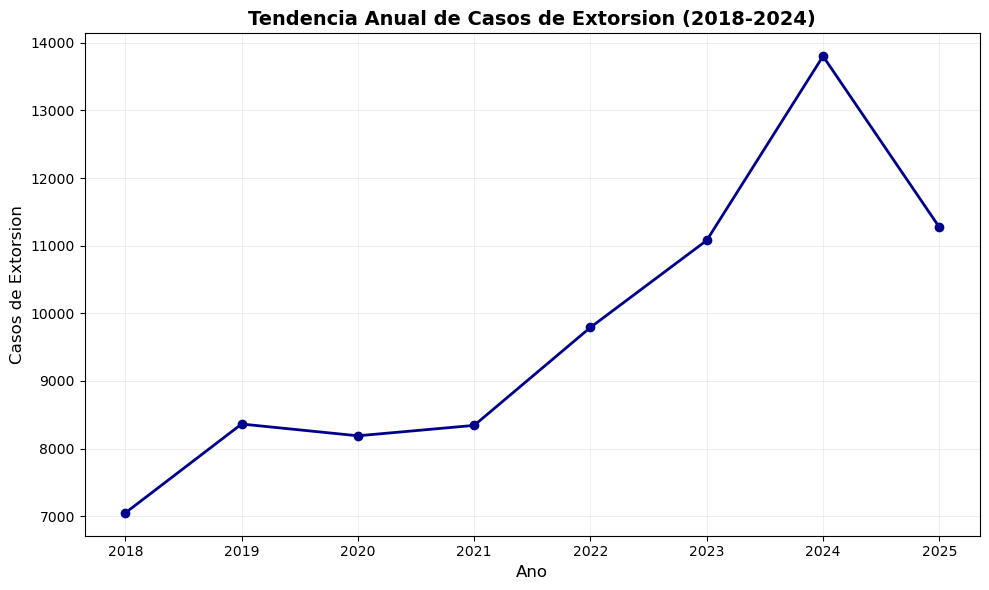

Grafico 01 guardado: 01_extorsion_tendencia_anual.png


In [5]:
# Filtrar desde 2018
df_ext = df_extorsion[df_extorsion['ano'] >= 2018].copy()

# Agrupar por ano
df_anual = df_ext.groupby('ano')['cantidad'].sum().reset_index()

# Crear grafico
fig, ax = plt.subplots(figsize=(10, 6))
df_anual.plot(x='ano', y='cantidad', kind='line', marker='o', ax=ax, color='darkblue', linewidth=2)

ax.set_title('Tendencia Anual de Casos de Extorsion (2018-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Casos de Extorsion', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend().remove()

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/01_extorsion_tendencia_anual.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 01 guardado: 01_extorsion_tendencia_anual.png")

### Grafico 02: Tendencia Mensual de Casos de Extorsion

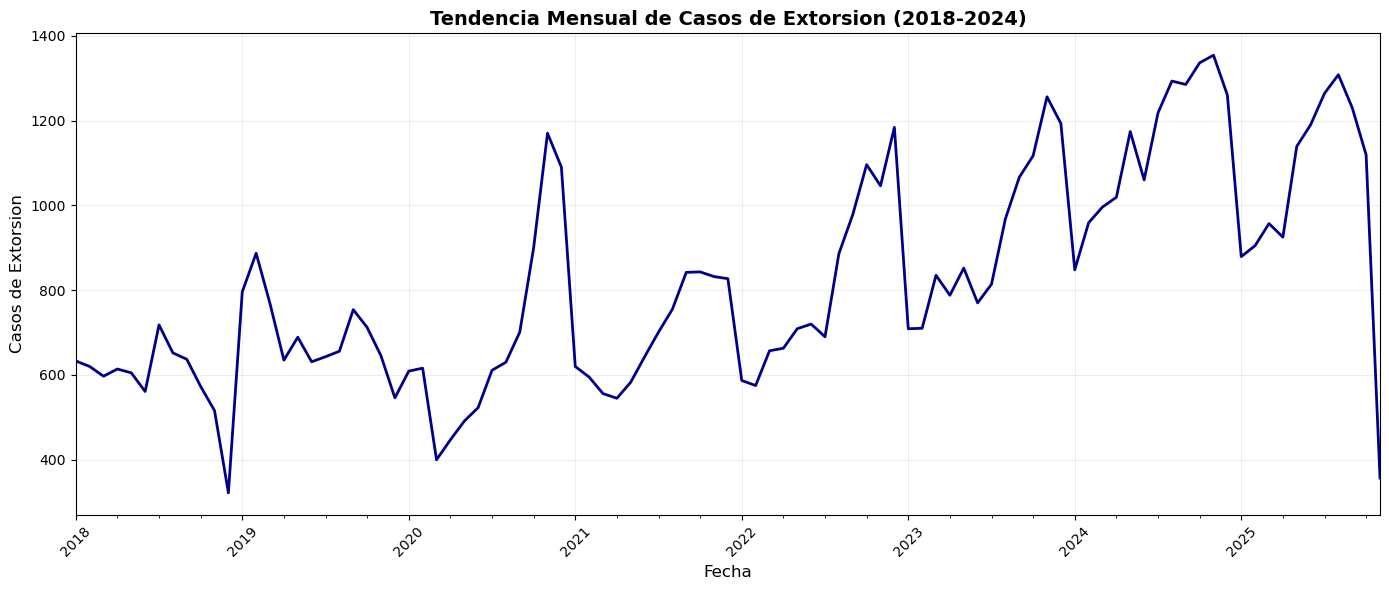

Grafico 02 guardado: 02_extorsion_tendencia_mensual.png


In [6]:
# Crear periodo ano-mes
df_ext['periodo'] = pd.to_datetime(df_ext['ano'].astype(str) + '-' + 
                                     df_ext['mes'].astype(str).str.zfill(2) + '-01')

# Agrupar por periodo
df_mensual = df_ext.groupby('periodo')['cantidad'].sum().reset_index()

# Crear grafico
fig, ax = plt.subplots(figsize=(14, 6))
df_mensual.plot(x='periodo', y='cantidad', kind='line', ax=ax, color='darkblue', linewidth=2)

ax.set_title('Tendencia Mensual de Casos de Extorsion (2018-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Casos de Extorsion', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend().remove()
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/02_extorsion_tendencia_mensual.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 02 guardado: 02_extorsion_tendencia_mensual.png")

### Grafico 03: Top 10 Departamentos por Extorsion

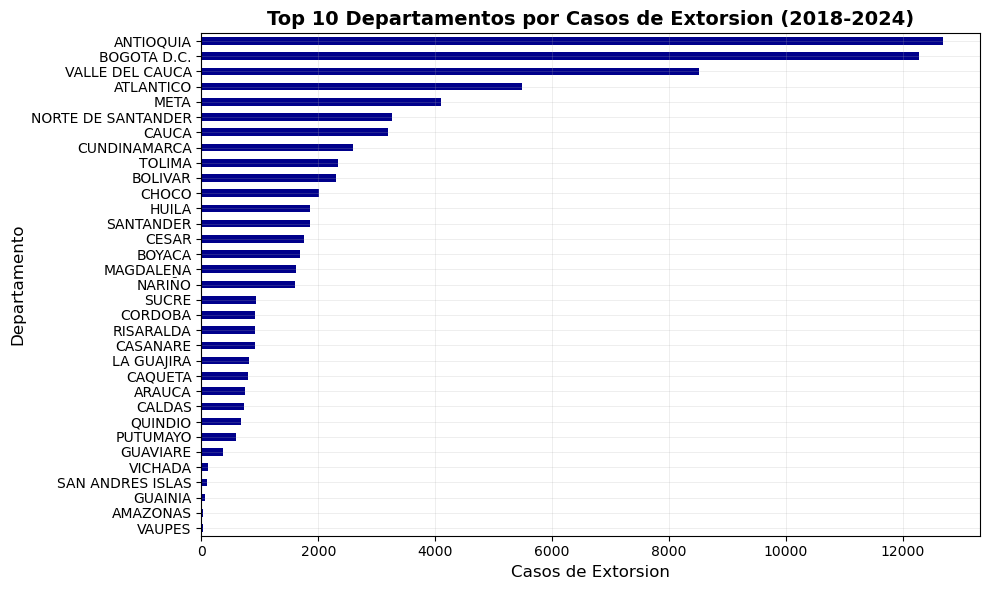

Grafico 03 guardado: 03_extorsion_top_departamentos.png


In [7]:
# Agrupar por departamento
top_dptos = df_ext.groupby('dpto_nombre')['cantidad'].sum().sort_values()

# Crear grafico
fig, ax = plt.subplots(figsize=(10, 6))
top_dptos.plot(kind='barh', ax=ax, color='darkblue')

ax.set_title('Top 10 Departamentos por Casos de Extorsion (2018-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Casos de Extorsion', fontsize=12)
ax.set_ylabel('Departamento', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/03_extorsion_top_departamentos.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 03 guardado: 03_extorsion_top_departamentos.png")

### Grafico 04: Distribucion de Extorsiones por Departamento (Boxplot)

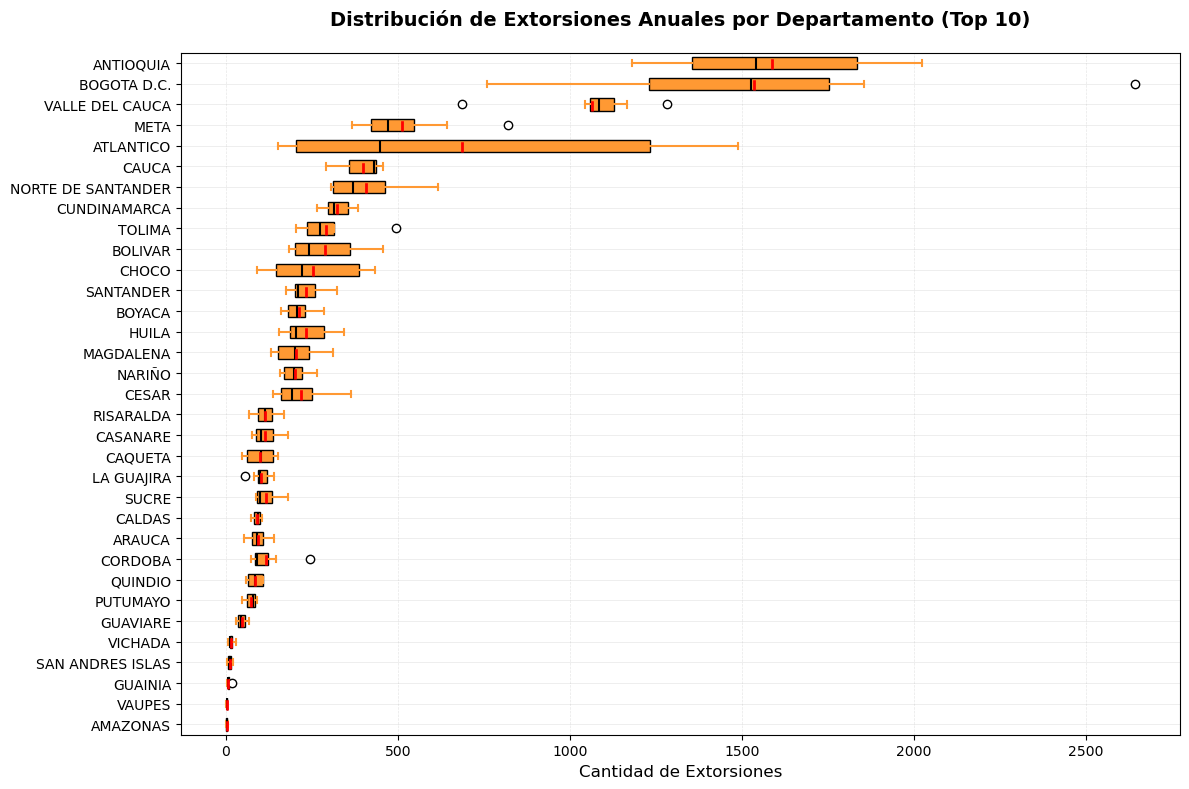

Grafico 04 guardado: 04_extorsion_boxplot_departamentos.png


In [8]:
# Agrupar por departamento y ano
df_dpto_ano = df_ext.groupby(['dpto_nombre', 'ano'])['cantidad'].sum().reset_index()

# Top 10 departamentos
top_dptos_list = df_dpto_ano.groupby('dpto_nombre')['cantidad'].sum().index
df_top = df_dpto_ano[df_dpto_ano['dpto_nombre'].isin(top_dptos_list)]

# Preparar datos para boxplot (ordenados por mediana)
data_by_dpto = []
labels = []
medianas = []

for dpto in top_dptos_list:
    dpto_data = df_top[df_top['dpto_nombre'] == dpto]['cantidad'].values
    data_by_dpto.append(dpto_data)
    labels.append(dpto)
    medianas.append(np.median(dpto_data))

# Ordenar por mediana
sorted_indices = np.argsort(medianas)
data_by_dpto = [data_by_dpto[i] for i in sorted_indices]
labels = [labels[i] for i in sorted_indices]

# Crear grafico
fig, ax = plt.subplots(figsize=(12, 8))

# Boxplot horizontal
bp = ax.boxplot(data_by_dpto, 
                vert=False,  # Horizontal
                patch_artist=True,  # Para personalizar colores
                showmeans=True,  # Mostrar media
                meanline=True,  # Media como línea
                widths=0.6,
                meanprops=dict(color='red', linewidth=2),  # Media en rojo
                medianprops=dict(color='black', linewidth=1.5),  # Mediana en negro
                boxprops=dict(facecolor='#FF9933', edgecolor='black', linewidth=1),  # Cajas naranjas
                whiskerprops=dict(color='#FF9933', linewidth=1.5),  # Bigotes naranjas
                capprops=dict(color='#FF9933', linewidth=1.5),  # Caps naranjas
                flierprops=dict(marker='o', markerfacecolor='white', markersize=6,
                               markeredgecolor='black', markeredgewidth=1))  # Outliers

# Configurar ejes
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Cantidad de Extorsiones', fontsize=12)
ax.set_title('Distribución de Extorsiones Anuales por Departamento (Top 10)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/04_extorsion_boxplot_departamentos.png', dpi=300, bbox_inches='tight')
plt.show()
print("Grafico 04 guardado: 04_extorsion_boxplot_departamentos.png")

## 5. Analisis de Poblacion

Graficos relacionados con proyecciones de poblacion

### Grafico 06: Evolucion de la Poblacion Urbana y Rural

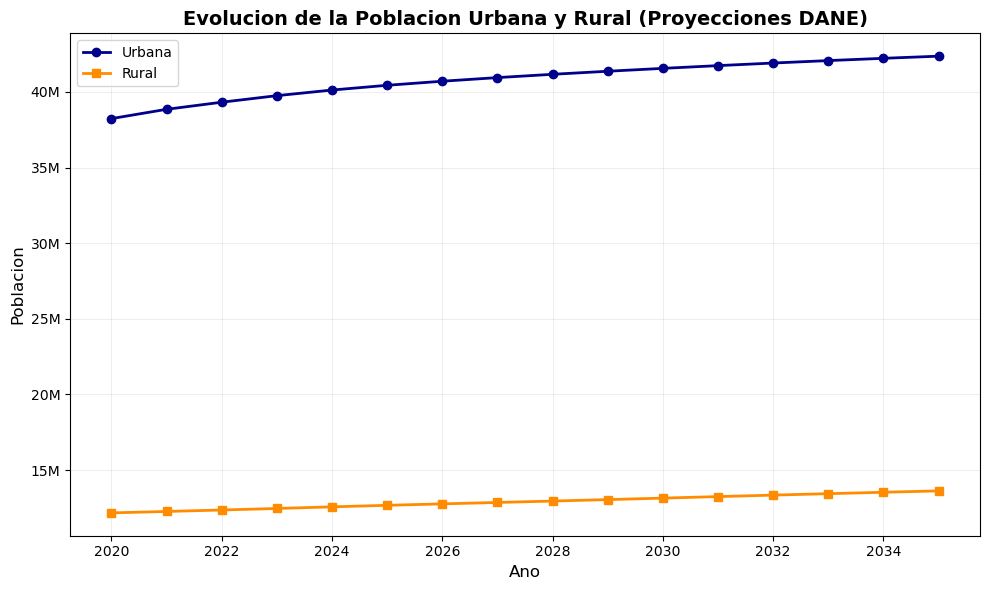

Grafico 06 guardado: 06_poblacion_urbana_rural.png


In [9]:
# Filtrar urbana y rural
df_pob_ur = df_poblacion[df_poblacion['tipo_area'].isin(['Urbana', 'Rural'])]

# Agrupar por ano y tipo
df_grouped = df_pob_ur.groupby(['ano', 'tipo_area'])['poblacion'].sum().unstack()

# Crear grafico
fig, ax = plt.subplots(figsize=(10, 6))
df_grouped['Urbana'].plot(kind='line', marker='o', ax=ax, label='Urbana', color='darkblue', linewidth=2)
df_grouped['Rural'].plot(kind='line', marker='s', ax=ax, label='Rural', color='darkorange', linewidth=2)

# Convertir a millones
ax.set_yticklabels([f'{x/1e6:.0f}M' for x in ax.get_yticks()])

ax.set_title('Evolucion de la Poblacion Urbana y Rural (Proyecciones DANE)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Poblacion', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/06_poblacion_urbana_rural.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 06 guardado: 06_poblacion_urbana_rural.png")

## 6. Analisis de PIB

Graficos relacionados con Producto Interno Bruto departamental

### Grafico 07: PIB por Sector Economico

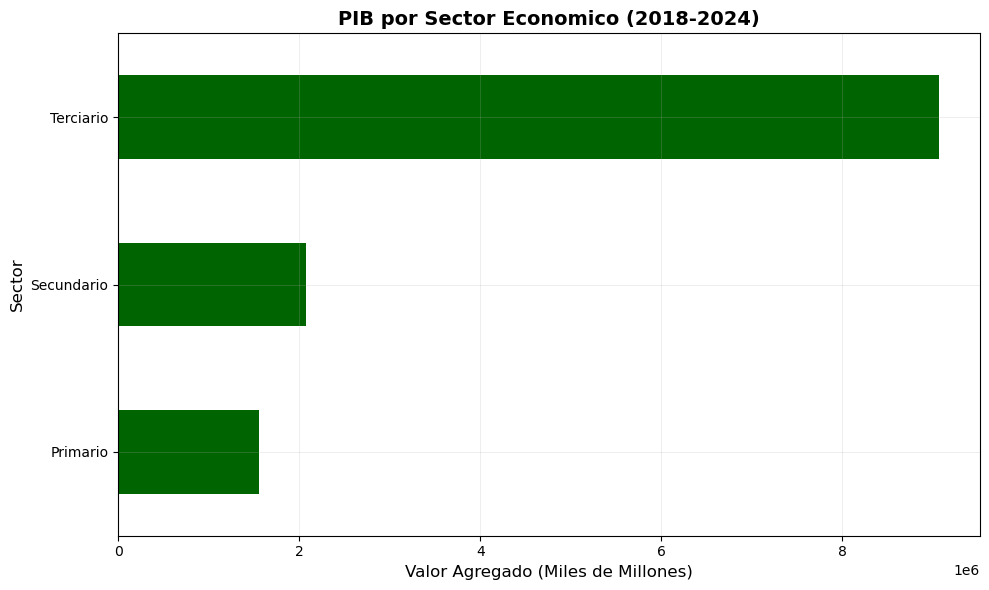

Grafico 07 guardado: 07_pib_sector_economico.png


In [10]:
# Filtrar desde 2018
df_pib_filtrado = df_pib[df_pib['ano'] >= 2018]

# Agrupar por sector
sector_total = df_pib_filtrado.groupby('sector')['valor_agregado'].sum().sort_values()

# Crear grafico
fig, ax = plt.subplots(figsize=(10, 6))
sector_total.plot(kind='barh', ax=ax, color='darkgreen')

ax.set_title('PIB por Sector Economico (2018-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Valor Agregado (Miles de Millones)', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/07_pib_sector_economico.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 07 guardado: 07_pib_sector_economico.png")

### Grafico 08: Relacion PIB per capita vs Extorsion

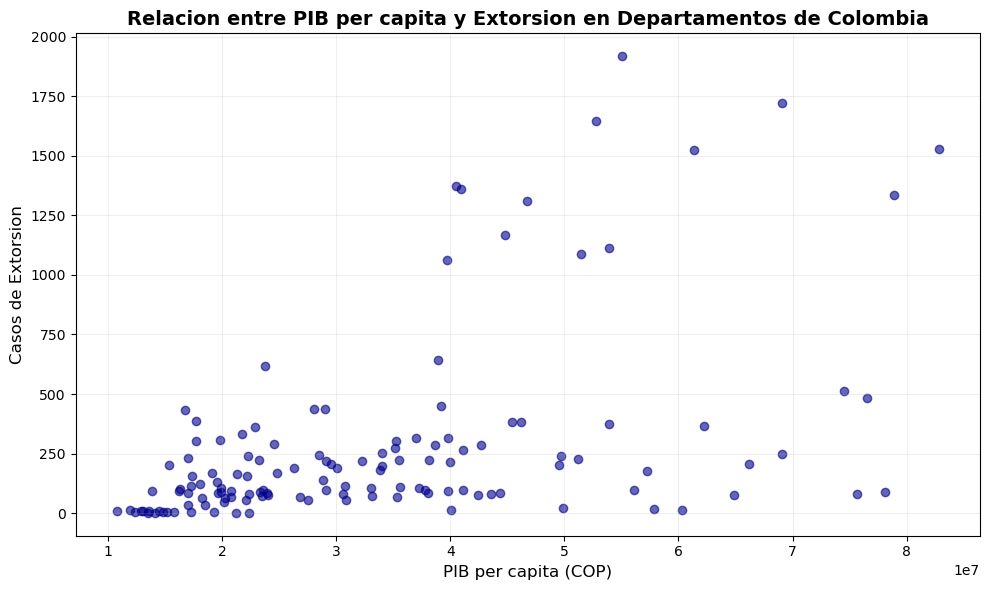

Grafico 08 guardado: 08_pib_vs_extorsion.png


In [11]:
# PIB por departamento
pib_dpto = df_pib.groupby(['cod_dpto', 'ano'])['valor_agregado'].sum().reset_index()

# Poblacion total por departamento
pob_dpto = df_poblacion[df_poblacion['tipo_area'] == 'Total'].groupby(['cod_dpto', 'ano'])['poblacion'].sum().reset_index()

# Extorsion por departamento
ext_dpto = df_extorsion.groupby(['cod_dpto', 'ano'])['cantidad'].sum().reset_index()

# Merge
df_merge = pib_dpto.merge(pob_dpto, on=['cod_dpto', 'ano'], how='inner')
df_merge = df_merge.merge(ext_dpto, on=['cod_dpto', 'ano'], how='inner')

# Calcular PIB per capita
df_merge['pib_per_capita'] = (df_merge['valor_agregado'] * 1e9) / df_merge['poblacion']

# Filtrar desde 2018
df_merge = df_merge[df_merge['ano'] >= 2018]

# Crear grafico
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_merge['pib_per_capita'], df_merge['cantidad'], alpha=0.6, color='darkblue')

ax.set_title('Relacion entre PIB per capita y Extorsion en Departamentos de Colombia', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('PIB per capita (COP)', fontsize=12)
ax.set_ylabel('Casos de Extorsion', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/08_pib_vs_extorsion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 08 guardado: 08_pib_vs_extorsion.png")

## 7. Analisis de Cobertura Movil

Graficos relacionados con cobertura de internet y telefonia movil

### Grafico 09: Evolucion de Penetracion de Internet por Ano

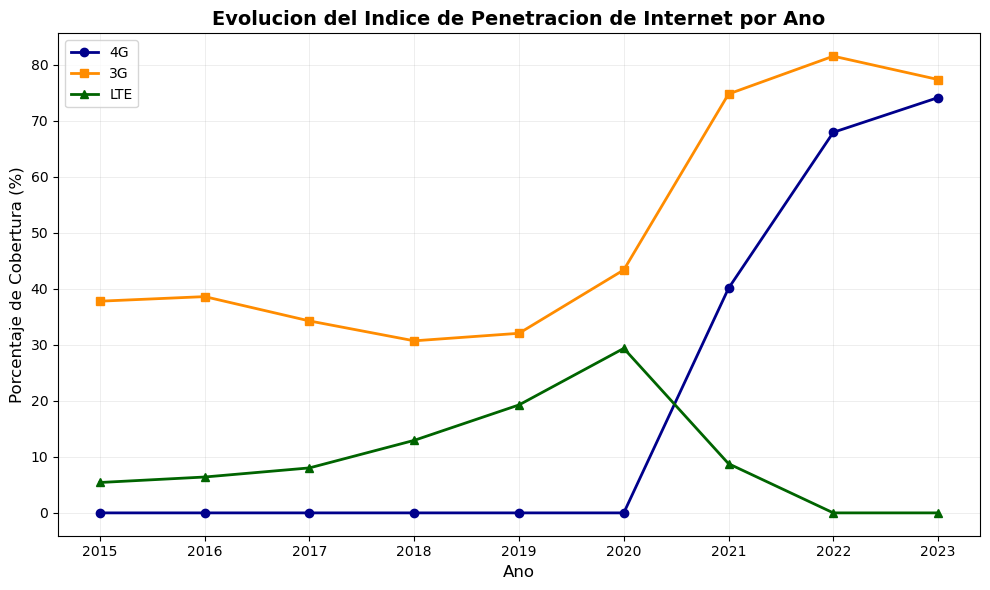

Grafico 09 guardado: 09_cobertura_penetracion_internet.png


In [12]:
# Filtrar desde 2015
df_cob = df_cobertura[df_cobertura['ano'] >= 2015]

# Calcular penetracion
penetracion = df_cob.groupby('ano').agg({
    'cobertura_4g': 'mean',
    'cobertura_3g': 'mean',
    'cobertura_lte': 'mean'
}).reset_index()

# Crear grafico
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(penetracion['ano'], penetracion['cobertura_4g']*100, marker='o', label='4G', 
        color='darkblue', linewidth=2)
ax.plot(penetracion['ano'], penetracion['cobertura_3g']*100, marker='s', label='3G', 
        color='darkorange', linewidth=2)
ax.plot(penetracion['ano'], penetracion['cobertura_lte']*100, marker='^', label='LTE', 
        color='darkgreen', linewidth=2)

ax.set_title('Evolucion del Indice de Penetracion de Internet por Ano', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Porcentaje de Cobertura (%)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/09_cobertura_penetracion_internet.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 09 guardado: 09_cobertura_penetracion_internet.png")

### Grafico 10: Distribucion de Cobertura por Proveedor

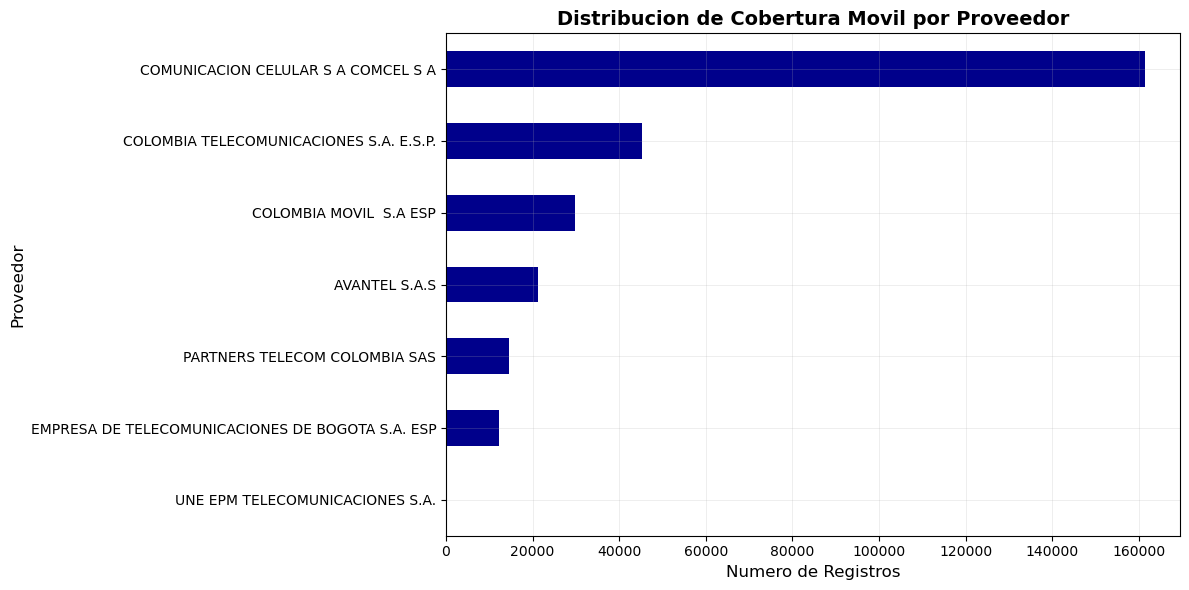

Grafico 10 guardado: 10_cobertura_por_proveedor.png


In [13]:
# Filtrar desde 2018
df_cob_filtrado = df_cobertura[df_cobertura['ano'] >= 2018]

# Contar por proveedor
prov_count = df_cob_filtrado['proveedor'].value_counts().head(8).sort_values()

# Crear grafico
fig, ax = plt.subplots(figsize=(12, 6))
prov_count.plot(kind='barh', ax=ax, color='darkblue')

ax.set_title('Distribucion de Cobertura Movil por Proveedor', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero de Registros', fontsize=12)
ax.set_ylabel('Proveedor', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/10_cobertura_por_proveedor.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 10 guardado: 10_cobertura_por_proveedor.png")

## 8. Analisis de Atentados y Acciones Subversivas

Graficos relacionados con acciones subversivas y atentados

### Grafico 11: Evolucion de Acciones Subversivas por Tipo

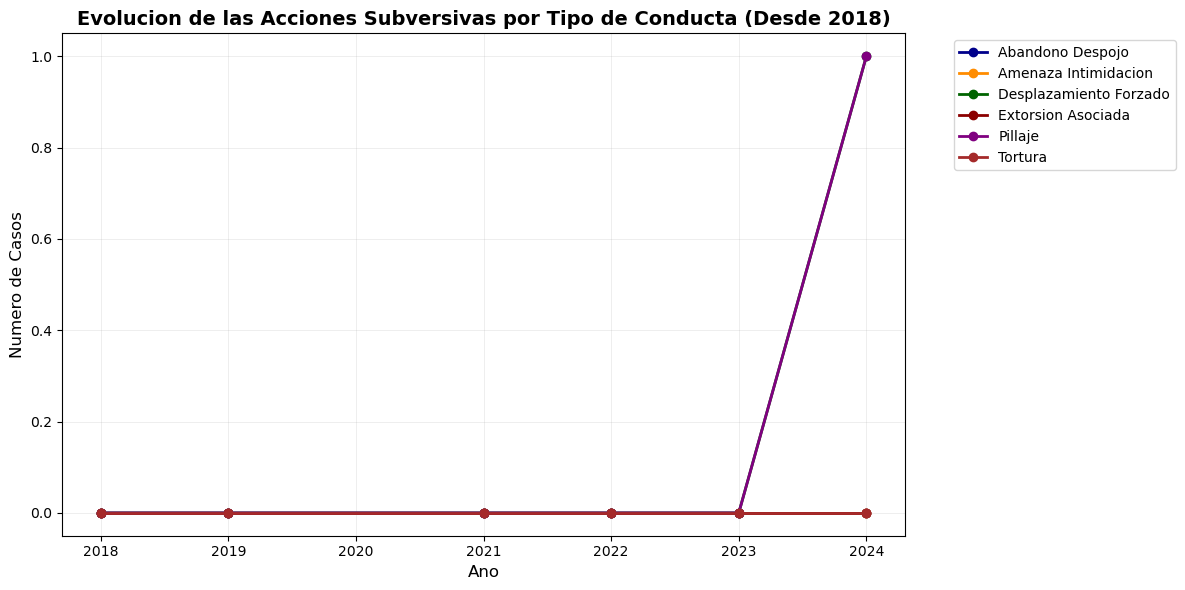

Grafico 11 guardado: 11_atentados_evolucion_tipo.png


In [14]:
# Filtrar desde 2018
df_atent_filtrado = df_atentados[df_atentados['ano'] >= 2018]

# Variables de interes
conductas = ['abandono_despojo', 'amenaza_intimidacion', 'desplazamiento_forzado', 
             'extorsion_asociada', 'pillaje', 'tortura']

# Agrupar por ano
df_year = df_atent_filtrado.groupby('ano')[conductas].sum()

# Crear grafico
fig, ax = plt.subplots(figsize=(12, 6))

colores = ['darkblue', 'darkorange', 'darkgreen', 'darkred', 'purple', 'brown']
for i, col in enumerate(conductas):
    ax.plot(df_year.index, df_year[col], marker='o', 
            label=col.replace('_', ' ').title(), linewidth=2, color=colores[i])

ax.set_title('Evolucion de las Acciones Subversivas por Tipo de Conducta (Desde 2018)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Numero de Casos', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/11_atentados_evolucion_tipo.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 11 guardado: 11_atentados_evolucion_tipo.png")

## 9. Analisis Comparativo de Delitos

Graficos que comparan diferentes tipos de delitos

### Grafico 12: Comparacion Homicidios vs Extorsion

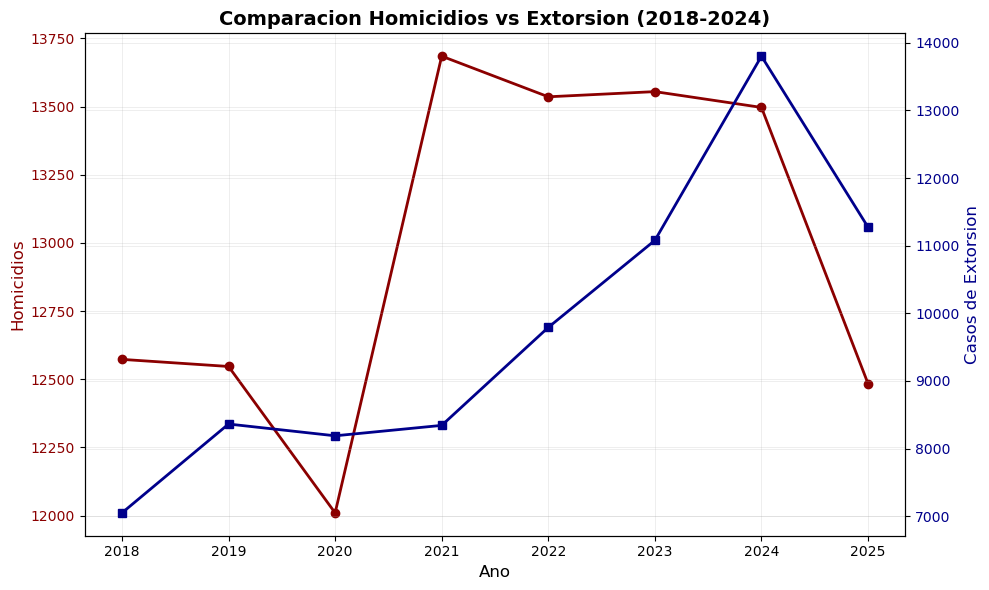

Grafico 12 guardado: 12_comparacion_homicidios_extorsion.png


In [15]:
# Filtrar desde 2018
df_hom = df_homicidio[df_homicidio['ano'] >= 2018]
df_ext_comp = df_extorsion[df_extorsion['ano'] >= 2018]

# Agrupar por ano
hom_anual = df_hom.groupby('ano')['cantidad'].sum().reset_index()
ext_anual = df_ext_comp.groupby('ano')['cantidad'].sum().reset_index()

# Crear grafico con doble eje Y
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(hom_anual['ano'], hom_anual['cantidad'], marker='o', 
         color='darkred', label='Homicidios', linewidth=2)
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Homicidios', fontsize=12, color='darkred')
ax1.tick_params(axis='y', labelcolor='darkred')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ext_anual['ano'], ext_anual['cantidad'], marker='s', 
         color='darkblue', label='Extorsion', linewidth=2)
ax2.set_ylabel('Casos de Extorsion', fontsize=12, color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

plt.title('Comparacion Homicidios vs Extorsion (2018-2024)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/12_comparacion_homicidios_extorsion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 12 guardado: 12_comparacion_homicidios_extorsion.png")

### Grafico 13: Matriz de Correlacion entre Delitos

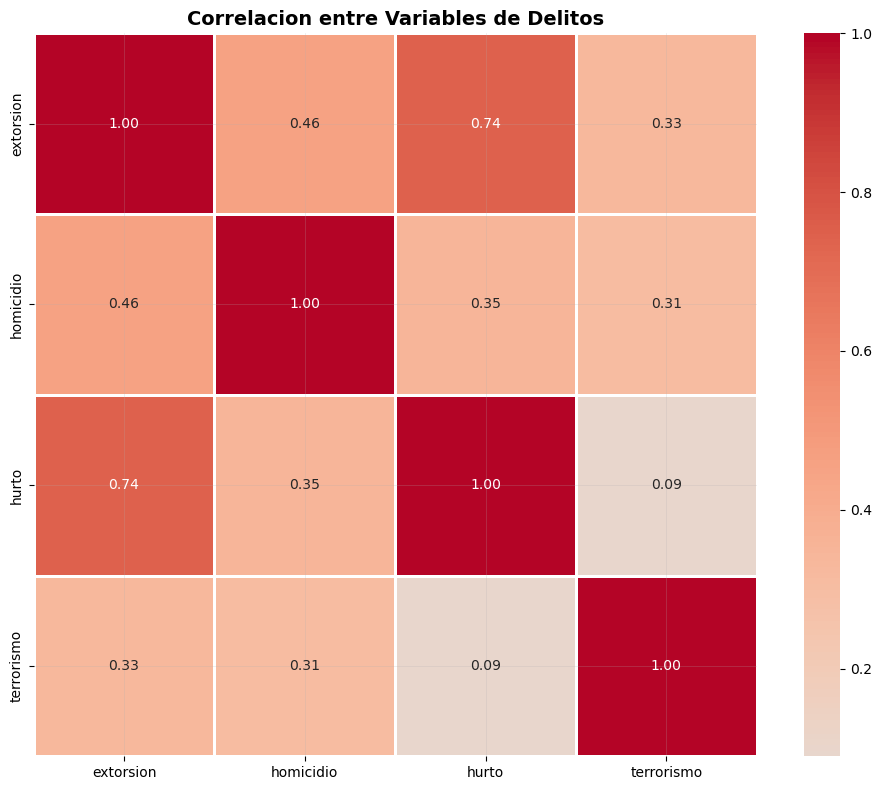

Grafico 13 guardado: 13_correlacion_delitos.png


In [16]:
# Preparar datos agregados por departamento y ano
ext_agg = df_extorsion.groupby(['cod_dpto', 'ano'])['cantidad'].sum().reset_index()
ext_agg = ext_agg.rename(columns={'cantidad': 'extorsion'})

hom_agg = df_homicidio.groupby(['cod_dpto', 'ano'])['cantidad'].sum().reset_index()
hom_agg = hom_agg.rename(columns={'cantidad': 'homicidio'})

hur_agg = df_hurto.groupby(['cod_dpto', 'ano'])['cantidad'].sum().reset_index()
hur_agg = hur_agg.rename(columns={'cantidad': 'hurto'})

ter_agg = df_terrorismo.groupby(['cod_dpto', 'ano'])['cantidad'].sum().reset_index()
ter_agg = ter_agg.rename(columns={'cantidad': 'terrorismo'})

# Merge
df_corr = ext_agg.merge(hom_agg, on=['cod_dpto', 'ano'], how='outer')
df_corr = df_corr.merge(hur_agg, on=['cod_dpto', 'ano'], how='outer')
df_corr = df_corr.merge(ter_agg, on=['cod_dpto', 'ano'], how='outer')

# Calcular correlacion
corr_matrix = df_corr[['extorsion', 'homicidio', 'hurto', 'terrorismo']].corr()

# Crear grafico
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            ax=ax, square=True, linewidths=1)

ax.set_title('Correlacion entre Variables de Delitos', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/13_correlacion_delitos.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 13 guardado: 13_correlacion_delitos.png")

## 10. Analisis de Estupefacientes

Graficos relacionados con incautaciones de estupefacientes

### Grafico 14: Incautaciones por Tipo de Sustancia

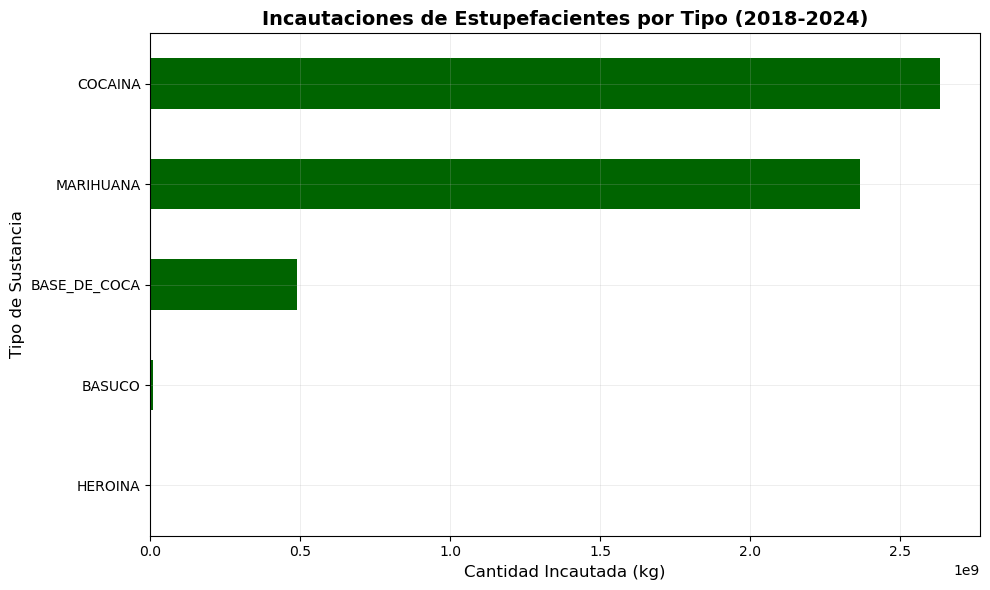

Grafico 14 guardado: 14_estupefacientes_por_tipo.png


In [17]:
# Filtrar desde 2018
df_est = df_estupefacientes[df_estupefacientes['ano'] >= 2018]

# Total por tipo
tipo_total = df_est.groupby('tipo_sustancia')['cantidad'].sum().sort_values()

# Crear grafico
fig, ax = plt.subplots(figsize=(10, 6))
tipo_total.plot(kind='barh', ax=ax, color='darkgreen')

ax.set_title('Incautaciones de Estupefacientes por Tipo (2018-2024)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad Incautada (kg)', fontsize=12)
ax.set_ylabel('Tipo de Sustancia', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/14_estupefacientes_por_tipo.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 14 guardado: 14_estupefacientes_por_tipo.png")

## 11. Analisis de Cultivos de Coca

Graficos relacionados con hectareas de cultivos de coca

### Grafico 15: Top 10 Departamentos por Hectareas de Coca

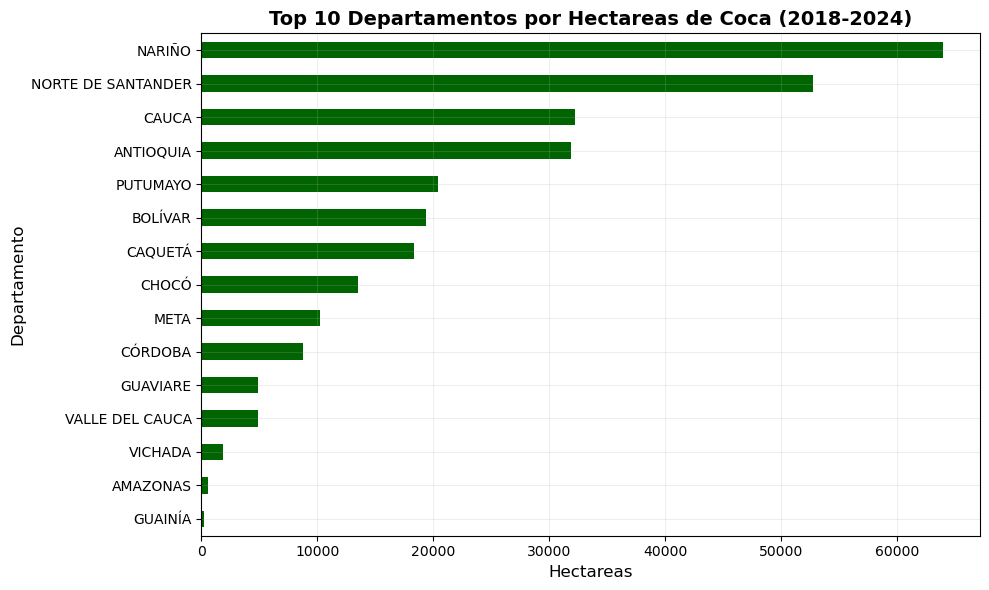

Grafico 15 guardado: 15_coca_top_departamentos.png


In [18]:
# Filtrar desde 2018
df_coca_filtrado = df_coca[df_coca['ano'] >= 2018]

# Top 10 departamentos
top_coca = df_coca_filtrado.groupby('dpto_nombre')['hectareas'].sum().nlargest(15).sort_values()

# Crear grafico
fig, ax = plt.subplots(figsize=(10, 6))
top_coca.plot(kind='barh', ax=ax, color='darkgreen')

ax.set_title('Top 10 Departamentos por Hectareas de Coca (2018-2024)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hectareas', fontsize=12)
ax.set_ylabel('Departamento', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/15_coca_top_departamentos.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 15 guardado: 15_coca_top_departamentos.png")

## 12. Resumen Final

In [19]:
import os

print("="*70)
print("ANALISIS DESCRIPTIVO COMPLETADO")
print("="*70)
print(f"\nGraficos generados en: {GRAFICOS_PATH}/")
print("\nArchivos creados:")

graficos = sorted([f for f in os.listdir(GRAFICOS_PATH) if f.endswith('.png')])
for i, g in enumerate(graficos, 1):
    print(f"  {i:02d}. {g}")

print(f"\nTotal: {len(graficos)} graficos")
print("="*70)

ANALISIS DESCRIPTIVO COMPLETADO

Graficos generados en: generated_data/descriptive_analysis/graficos/

Archivos creados:
  01. 01_extorsion_tendencia_anual.png
  02. 02_extorsion_tendencia_mensual.png
  03. 03_extorsion_top_departamentos.png
  04. 04_extorsion_boxplot_departamentos.png
  05. 06_poblacion_urbana_rural.png
  06. 07_pib_sector_economico.png
  07. 08_pib_vs_extorsion.png
  08. 09_cobertura_penetracion_internet.png
  09. 10_cobertura_por_proveedor.png
  10. 11_atentados_evolucion_tipo.png
  11. 12_comparacion_homicidios_extorsion.png
  12. 13_correlacion_delitos.png
  13. 14_estupefacientes_por_tipo.png
  14. 15_coca_top_departamentos.png

Total: 14 graficos


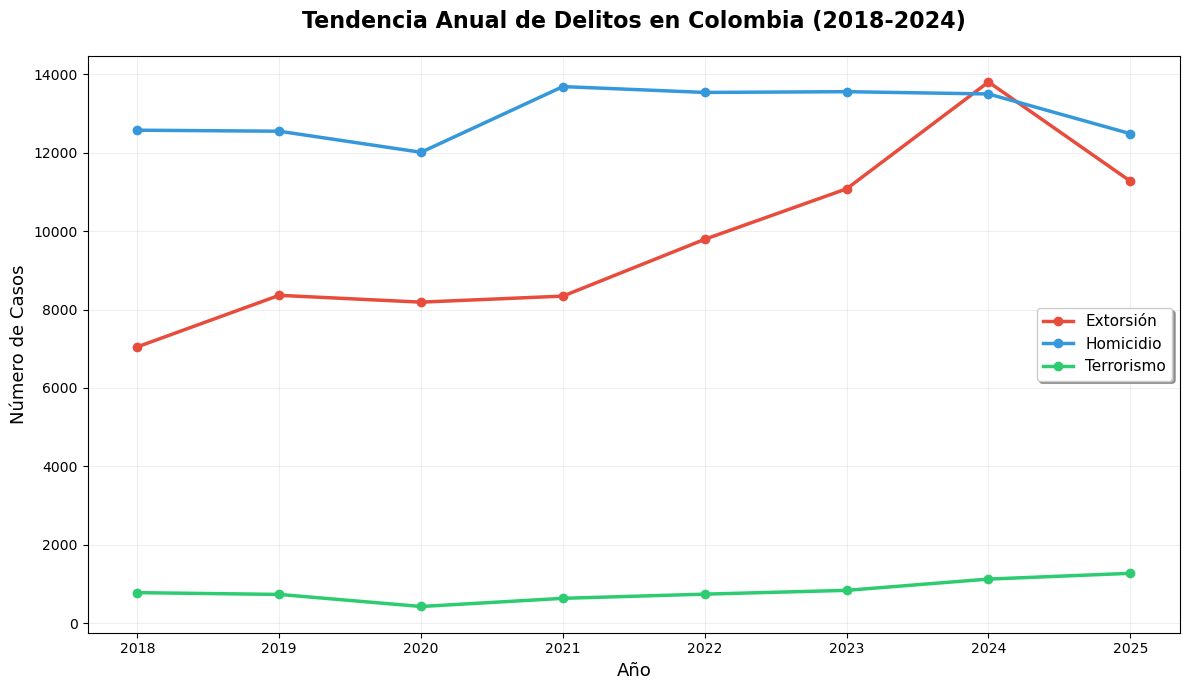

Gráfico 16 guardado: 16_delitos_tendencia_anual_comparacion.png


In [20]:
# ============================================================================
# GRAFICOS ADICIONALES - COMPARACION DE DELITOS
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# GRAFICO 1: TENDENCIA ANUAL DE TODOS LOS DELITOS (2018-2024)
# ----------------------------------------------------------------------------

# Preparar datos de cada delito
delitos_dict = {}

# Extorsion
df_ext = df_extorsion[df_extorsion['ano'] >= 2018].copy()
delitos_dict['Extorsión'] = df_ext.groupby('ano')['cantidad'].sum()

# Homicidio
df_hom = df_homicidio[df_homicidio['ano'] >= 2018].copy()
delitos_dict['Homicidio'] = df_hom.groupby('ano')['cantidad'].sum()

# Hurto
#df_hur = df_hurto[df_hurto['ano'] >= 2018].copy()
#delitos_dict['Hurto'] = df_hur.groupby('ano')['cantidad'].sum()

# Terrorismo
df_ter = df_terrorismo[df_terrorismo['ano'] >= 2018].copy()
delitos_dict['Terrorismo'] = df_ter.groupby('ano')['cantidad'].sum()

# Estupefacientes
#df_est = df_estupefacientes[df_estupefacientes['ano'] >= 2018].copy()
#delitos_dict['Estupefacientes'] = df_est.groupby('ano')['cantidad'].sum()

# Crear DataFrame consolidado
df_delitos = pd.DataFrame(delitos_dict)

# Crear grafico
fig, ax = plt.subplots(figsize=(12, 7))

colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for i, columna in enumerate(df_delitos.columns):
    ax.plot(df_delitos.index, df_delitos[columna], 
            marker='o', linewidth=2.5, label=columna, 
            color=colores[i], markersize=6)

ax.set_title('Tendencia Anual de Delitos en Colombia (2018-2024)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Año', fontsize=13)
ax.set_ylabel('Número de Casos', fontsize=13)
ax.legend(loc='best', fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/16_delitos_tendencia_anual_comparacion.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 16 guardado: 16_delitos_tendencia_anual_comparacion.png")

In [21]:
# ============================================================================
# GRAFICOS DE BARRAS POR DELITO
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# FUNCIONES GENERICAS
# ----------------------------------------------------------------------------

def graficar_delito_crudo(df, nombre_delito, color, numero_grafico, ano_inicio=2018):
    """
    Genera grafico de barras horizontales para casos crudos de un delito.
    
    Parametros:
    - df: DataFrame con columnas 'ano', 'dpto_nombre', 'cantidad'
    - nombre_delito: Nombre del delito para el titulo (ej: 'Homicidio')
    - color: Color de las barras (ej: '#e74c3c')
    - numero_grafico: Numero del grafico para el nombre del archivo
    - ano_inicio: Año desde el cual filtrar (default: 2018)
    """
    # Filtrar y agrupar
    df_filtrado = df[df['ano'] >= ano_inicio].copy()
    top_dptos = df_filtrado.groupby('dpto_nombre')['cantidad'].sum().sort_values()
    
    # Calcular total para porcentajes
    total = df_filtrado['cantidad'].sum()
    
    # Crear grafico
    fig, ax = plt.subplots(figsize=(10, 6))
    top_dptos.plot(kind='barh', ax=ax, color=color)
    
    # Ajustar límite del eje X
    max_val = top_dptos.max()
    ax.set_xlim(0, max_val * 1.15)
    
    # Agregar etiquetas con porcentaje
    for i, (idx, valor) in enumerate(top_dptos.items()):
        porcentaje = (valor / total) * 100
        ax.text(valor + (max_val * 0.01), i, f'{porcentaje:.1f}%', 
                va='center', ha='left', fontsize=10)
    
    ax.set_title(f'Departamentos por Casos de {nombre_delito} ({ano_inicio}-2024)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel(f'Casos de {nombre_delito}', fontsize=12)
    ax.set_ylabel('Departamento', fontsize=12)
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(f'{GRAFICOS_PATH}/{numero_grafico:02d}_{nombre_delito.lower()}_top_departamentos.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Grafico {numero_grafico} guardado: {numero_grafico:02d}_{nombre_delito.lower()}_top_departamentos.png")

In [22]:
def graficar_delito_ponderado(df, nombre_delito, color, numero_grafico, pob_dpto, ano_inicio=2018, n_top=40):
    """
    Genera grafico de barras horizontales para tasa ponderada por poblacion.
    
    Parametros:
    - df: DataFrame con columnas 'ano', 'cod_dpto', 'dpto_nombre', 'cantidad'
    - nombre_delito: Nombre del delito para el titulo (ej: 'Homicidio')
    - color: Color de las barras (ej: '#e74c3c')
    - numero_grafico: Numero del grafico para el nombre del archivo
    - pob_dpto: DataFrame con 'cod_dpto' y 'poblacion_promedio'
    - ano_inicio: Año desde el cual filtrar (default: 2018)
    - n_top: Numero de departamentos a mostrar (default: 40, o sea todos)
    """
    # Filtrar y agrupar
    df_filtrado = df[df['ano'] >= ano_inicio].copy()
    dpto = df_filtrado.groupby(['cod_dpto', 'dpto_nombre'])['cantidad'].sum().reset_index()
    
    # Merge con poblacion
    dpto = dpto.merge(pob_dpto, on='cod_dpto', how='left')
    dpto = dpto.dropna(subset=['poblacion_promedio'])
    
    # Calcular tasa
    dpto['tasa_por_100k'] = (dpto['cantidad'] / dpto['poblacion_promedio']) * 100000
    
    # Top N por tasa
    top_pond = dpto.nlargest(n_top, 'tasa_por_100k').sort_values('tasa_por_100k')
    total_casos = dpto['cantidad'].sum()
    
    # Crear grafico
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_pond['dpto_nombre'], top_pond['tasa_por_100k'], color=color)
    
    # Ajustar límite del eje X
    max_val = top_pond['tasa_por_100k'].max()
    ax.set_xlim(0, max_val * 1.15)
    
    # Agregar etiquetas con porcentaje
    for idx, row in top_pond.iterrows():
        porcentaje = (row['cantidad'] / total_casos) * 100
        ax.text(row['tasa_por_100k'] + (max_val * 0.01), 
                row['dpto_nombre'], 
                f'{porcentaje:.1f}%', 
                va='center', ha='left', fontsize=10)
    
    ax.set_title(f'Departamentos por Tasa de {nombre_delito} por 100,000 hab ({ano_inicio}-2024)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Tasa por 100,000 habitantes', fontsize=12)
    ax.set_ylabel('Departamento', fontsize=12)
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(f'{GRAFICOS_PATH}/{numero_grafico:02d}_{nombre_delito.lower()}_tasa_departamentos.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Grafico {numero_grafico} guardado: {numero_grafico:02d}_{nombre_delito.lower()}_tasa_departamentos.png")

In [23]:
# ----------------------------------------------------------------------------
# PREPARAR POBLACION
# ----------------------------------------------------------------------------

df_pob = df_poblacion[(df_poblacion['ano'] >= 2018) & 
                      (df_poblacion['tipo_area'] == 'Total')].copy()

# Sumar población por departamento y año
pob_dpto_ano = df_pob.groupby(['cod_dpto', 'ano'])['poblacion'].sum().reset_index()

# Promediar por departamento
pob_dpto = pob_dpto_ano.groupby('cod_dpto')['poblacion'].mean().reset_index()
pob_dpto.columns = ['cod_dpto', 'poblacion_promedio']

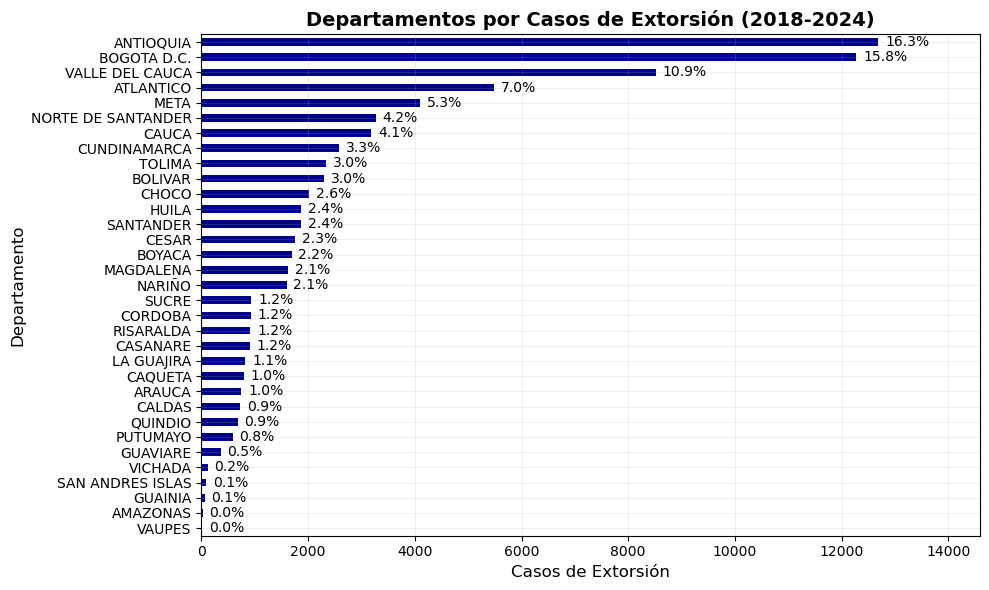

Grafico 20 guardado: 20_extorsión_top_departamentos.png


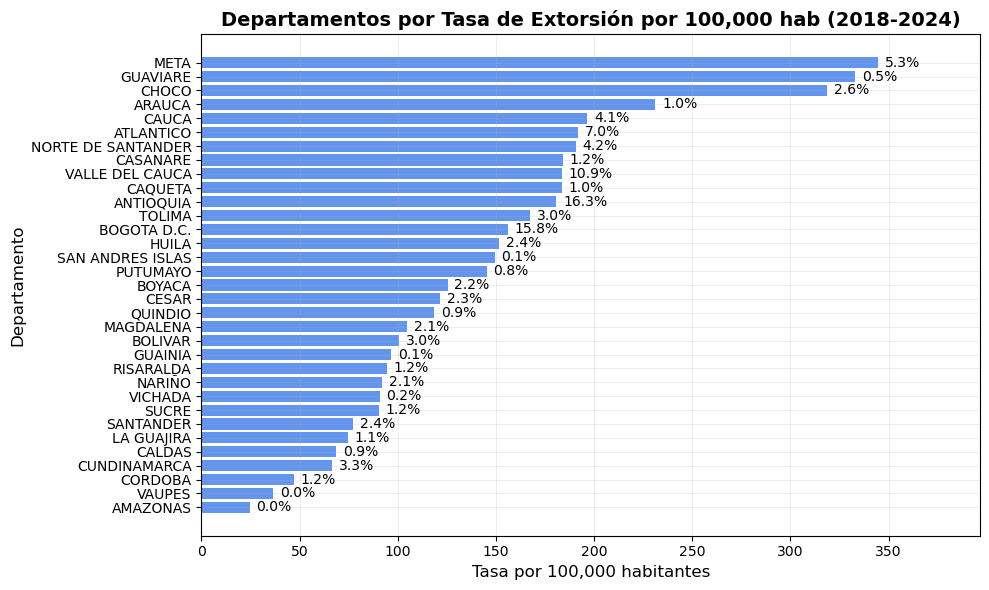

Grafico 20 guardado: 20_extorsión_tasa_departamentos.png


In [24]:
graficar_delito_crudo(df_extorsion, 'Extorsión', '#00008B', 20)      # darkblue original
graficar_delito_ponderado(df_extorsion, 'Extorsión', '#6495ED', 20, pob_dpto)  # cornflowerblue (claro)

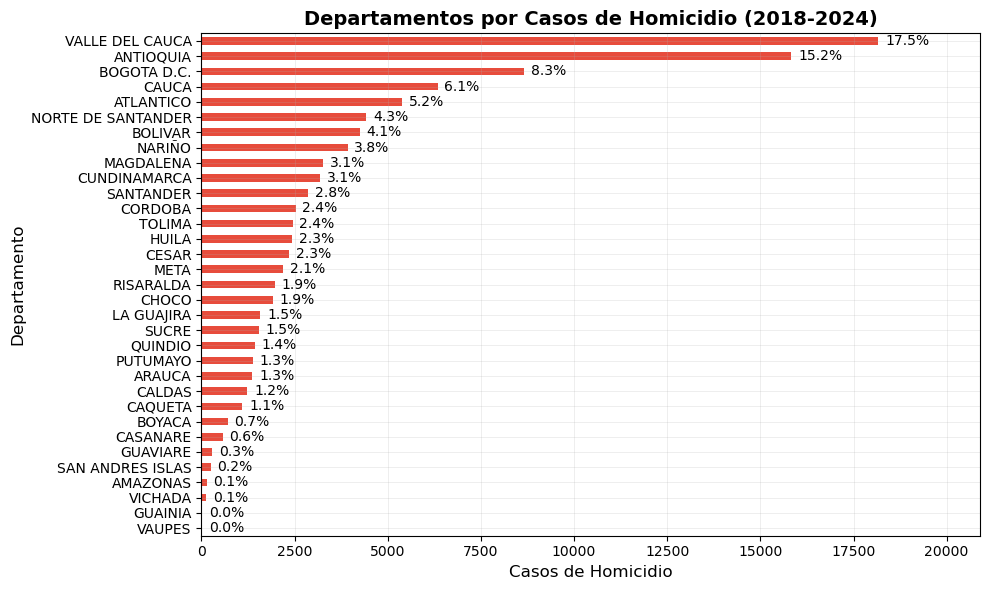

Grafico 40 guardado: 40_homicidio_top_departamentos.png


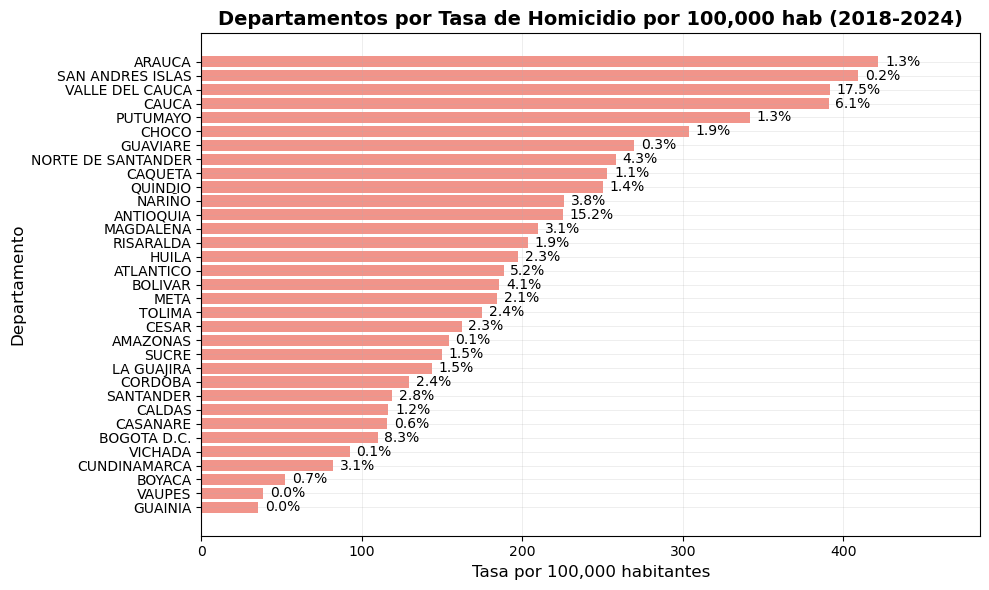

Grafico 40 guardado: 40_homicidio_tasa_departamentos.png


In [25]:
graficar_delito_crudo(df_homicidio, 'Homicidio', '#e74c3c', 40)      # rojo original
graficar_delito_ponderado(df_homicidio, 'Homicidio', '#F1948A', 40, pob_dpto)  # rojo claro

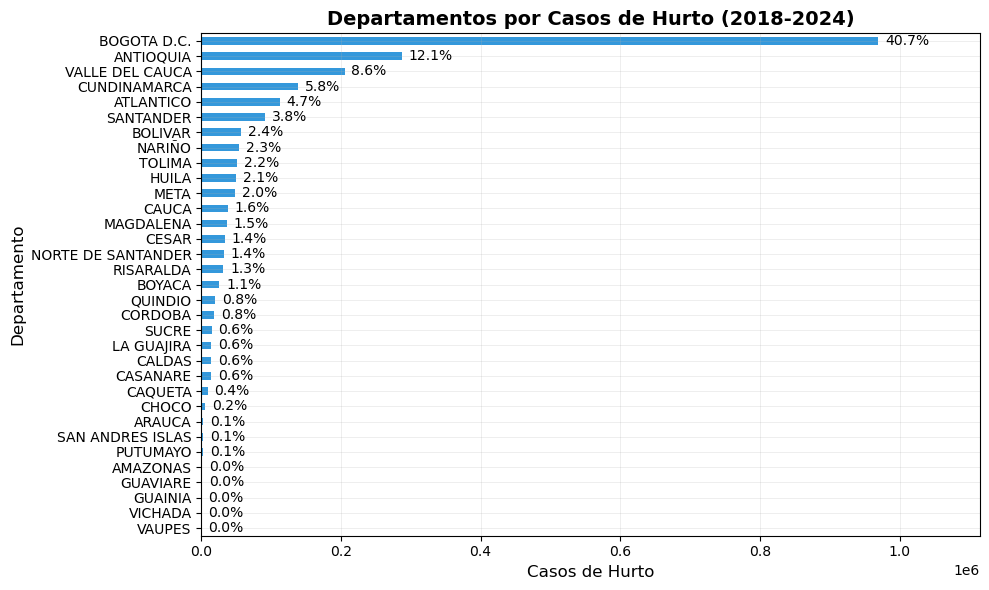

Grafico 17 guardado: 17_hurto_top_departamentos.png


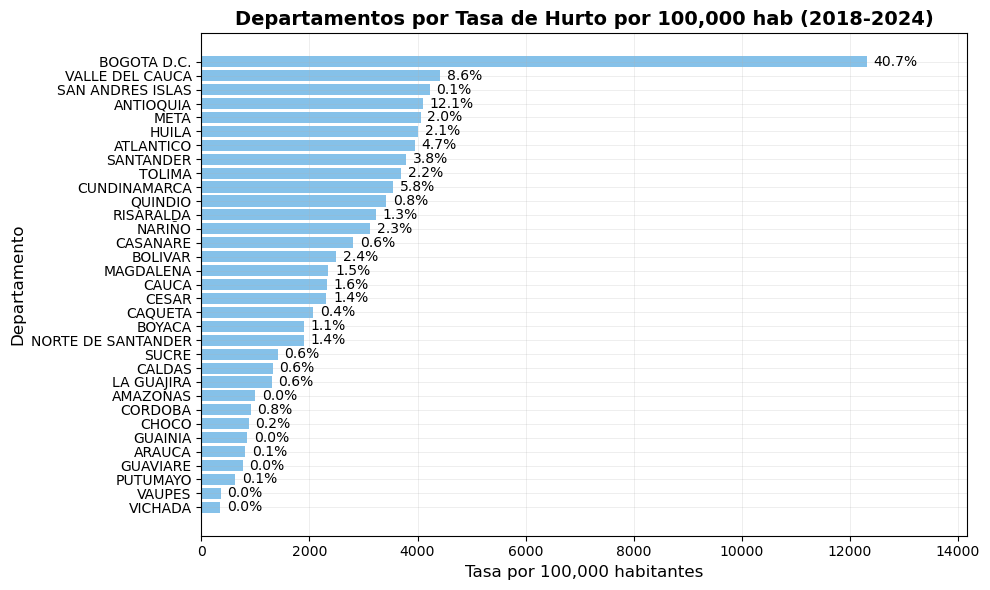

Grafico 22 guardado: 22_hurto_tasa_departamentos.png


In [26]:
graficar_delito_crudo(df_hurto, 'Hurto', '#3498db', 17)             # azul original
graficar_delito_ponderado(df_hurto, 'Hurto', '#85C1E9', 22, pob_dpto)        # azul claro

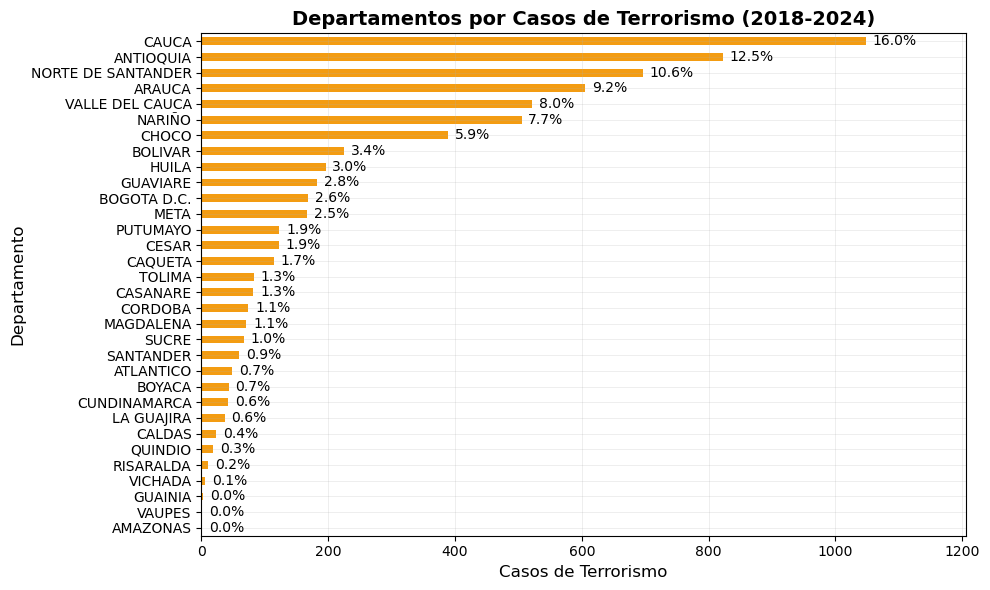

Grafico 18 guardado: 18_terrorismo_top_departamentos.png


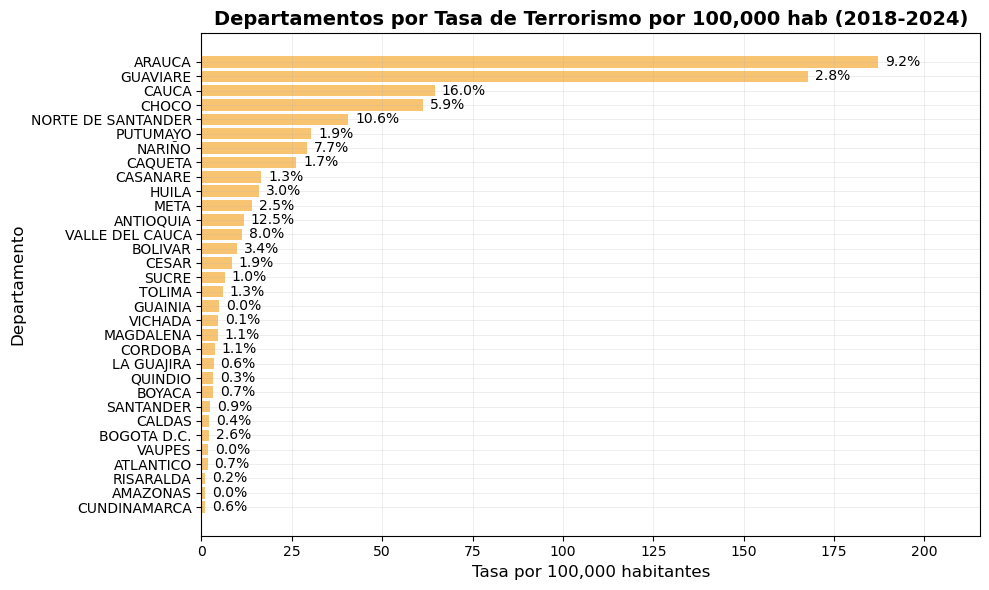

Grafico 23 guardado: 23_terrorismo_tasa_departamentos.png


In [27]:
graficar_delito_crudo(df_terrorismo, 'Terrorismo', '#f39c12', 18)   # naranja original
graficar_delito_ponderado(df_terrorismo, 'Terrorismo', '#F8C471', 23, pob_dpto)  # naranja claro

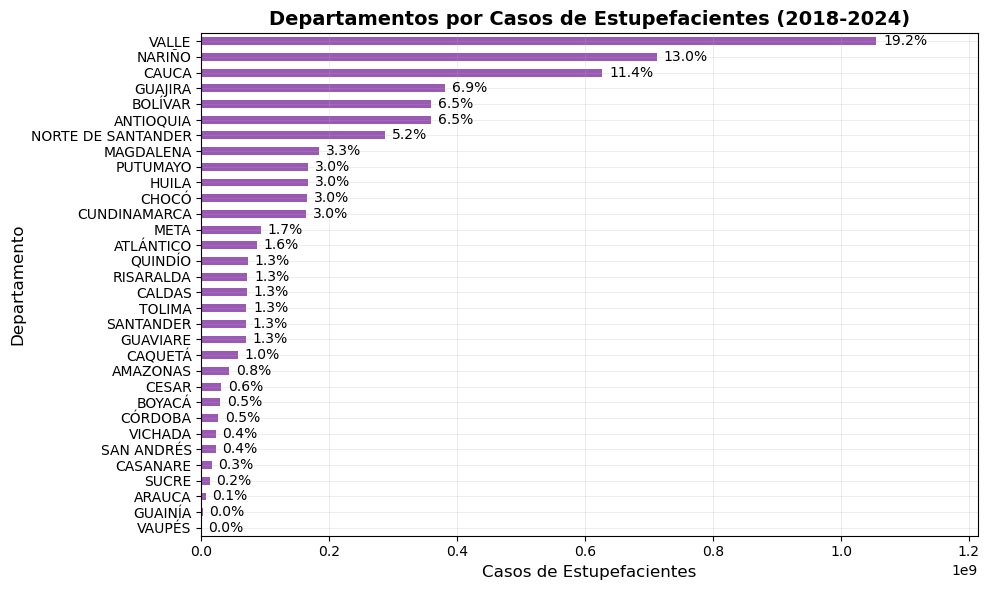

Grafico 19 guardado: 19_estupefacientes_top_departamentos.png


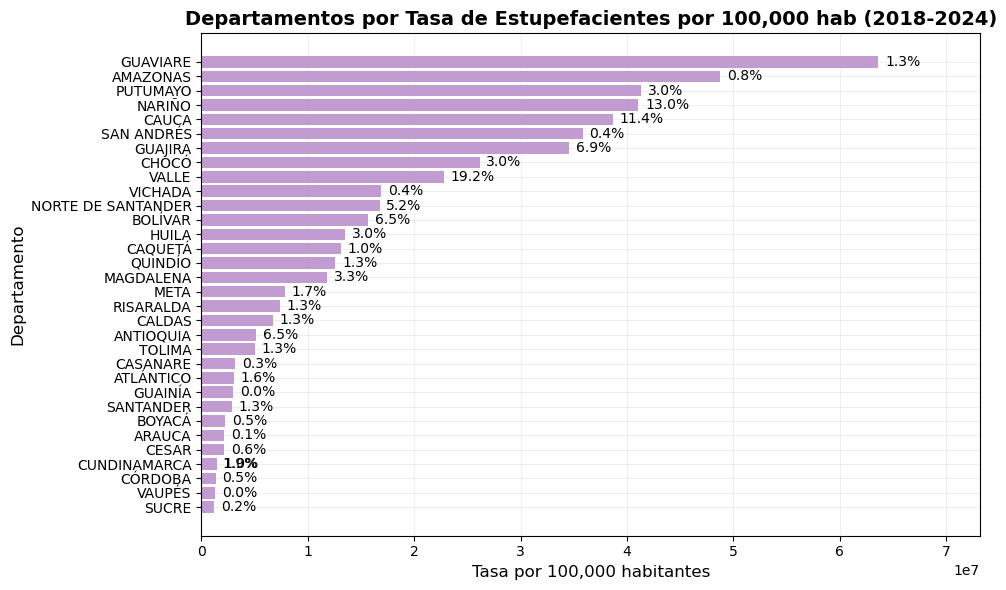

Grafico 24 guardado: 24_estupefacientes_tasa_departamentos.png


In [28]:
graficar_delito_crudo(df_estupefacientes, 'Estupefacientes', '#9b59b6', 19)  # púrpura original
graficar_delito_ponderado(df_estupefacientes, 'Estupefacientes', '#C39BD3', 24, pob_dpto)  # púrpura claro

In [29]:
# ============================================================================
# RESUMEN ESTADISTICO DEL ANALISIS DESCRIPTIVO
# ============================================================================

import pandas as pd
import numpy as np

print("="*80)
print("GENERANDO RESUMENES ESTADISTICOS PARA ANALISIS DESCRIPTIVO")
print("="*80)

# ----------------------------------------------------------------------------
# 1. TENDENCIA ANUAL DE EXTORSION (2018-2024)
# ----------------------------------------------------------------------------

df_ext = df_extorsion[df_extorsion['ano'] >= 2018].copy()
df_anual = df_ext.groupby('ano')['cantidad'].sum().reset_index()

print("\n" + "="*80)
print("1. TENDENCIA ANUAL DE EXTORSION (2018-2024)")
print("="*80)
print(df_anual.to_string(index=False))

# Estadísticas adicionales
total_periodo = df_anual['cantidad'].sum()
promedio_anual = df_anual['cantidad'].mean()
ano_mayor = df_anual.loc[df_anual['cantidad'].idxmax(), 'ano']
casos_mayor = df_anual['cantidad'].max()
ano_menor = df_anual.loc[df_anual['cantidad'].idxmin(), 'ano']
casos_menor = df_anual['cantidad'].min()
variacion_total = ((casos_mayor - casos_menor) / casos_menor) * 100

print(f"\nEstadísticas:")
print(f"  - Total periodo: {total_periodo:,} casos")
print(f"  - Promedio anual: {promedio_anual:,.1f} casos")
print(f"  - Año con más casos: {int(ano_mayor)} ({int(casos_mayor):,} casos)")
print(f"  - Año con menos casos: {int(ano_menor)} ({int(casos_menor):,} casos)")
print(f"  - Variación máx-min: {variacion_total:.1f}%")


# ----------------------------------------------------------------------------
# 2. TOP DEPARTAMENTOS POR DELITO (CASOS CRUDOS)
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("2. TOP 10 DEPARTAMENTOS POR CASOS CRUDOS (2018-2024)")
print("="*80)

# Extorsión
ext_dpto = df_ext.groupby('dpto_nombre')['cantidad'].sum().reset_index()
ext_dpto['porcentaje'] = (ext_dpto['cantidad'] / ext_dpto['cantidad'].sum()) * 100
ext_dpto = ext_dpto.sort_values('cantidad', ascending=False).head(10)
print("\nEXTORSIÓN:")
print(ext_dpto.to_string(index=False))

# Homicidio
df_hom = df_homicidio[df_homicidio['ano'] >= 2018].copy()
hom_dpto = df_hom.groupby('dpto_nombre')['cantidad'].sum().reset_index()
hom_dpto['porcentaje'] = (hom_dpto['cantidad'] / hom_dpto['cantidad'].sum()) * 100
hom_dpto = hom_dpto.sort_values('cantidad', ascending=False).head(10)
print("\nHOMICIDIO:")
print(hom_dpto.to_string(index=False))

# Hurto
df_hur = df_hurto[df_hurto['ano'] >= 2018].copy()
hur_dpto = df_hur.groupby('dpto_nombre')['cantidad'].sum().reset_index()
hur_dpto['porcentaje'] = (hur_dpto['cantidad'] / hur_dpto['cantidad'].sum()) * 100
hur_dpto = hur_dpto.sort_values('cantidad', ascending=False).head(10)
print("\nHURTO:")
print(hur_dpto.to_string(index=False))

# Terrorismo
df_ter = df_terrorismo[df_terrorismo['ano'] >= 2018].copy()
ter_dpto = df_ter.groupby('dpto_nombre')['cantidad'].sum().reset_index()
ter_dpto['porcentaje'] = (ter_dpto['cantidad'] / ter_dpto['cantidad'].sum()) * 100
ter_dpto = ter_dpto.sort_values('cantidad', ascending=False).head(10)
print("\nTERRORISMO:")
print(ter_dpto.to_string(index=False))

# Estupefacientes
df_est = df_estupefacientes[df_estupefacientes['ano'] >= 2018].copy()
est_dpto = df_est.groupby('dpto_nombre')['cantidad'].sum().reset_index()
est_dpto['porcentaje'] = (est_dpto['cantidad'] / est_dpto['cantidad'].sum()) * 100
est_dpto = est_dpto.sort_values('cantidad', ascending=False).head(10)
print("\nESTUPEFACIENTES:")
print(est_dpto.to_string(index=False))


# ----------------------------------------------------------------------------
# 3. TASAS PONDERADAS POR POBLACION (TOP 10)
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("3. TOP 10 DEPARTAMENTOS POR TASA POR 100,000 HAB (2018-2024)")
print("="*80)

# Preparar población
df_pob = df_poblacion[(df_poblacion['ano'] >= 2018) & 
                      (df_poblacion['tipo_area'] == 'Total')].copy()
pob_dpto_ano = df_pob.groupby(['cod_dpto', 'ano'])['poblacion'].sum().reset_index()
pob_dpto = pob_dpto_ano.groupby('cod_dpto')['poblacion'].mean().reset_index()
pob_dpto.columns = ['cod_dpto', 'poblacion_promedio']

# Extorsión
ext_tasa = df_ext.groupby(['cod_dpto', 'dpto_nombre'])['cantidad'].sum().reset_index()
ext_tasa = ext_tasa.merge(pob_dpto, on='cod_dpto', how='left').dropna()
ext_tasa['tasa_por_100k'] = (ext_tasa['cantidad'] / ext_tasa['poblacion_promedio']) * 100000
ext_tasa['porcentaje'] = (ext_tasa['cantidad'] / ext_tasa['cantidad'].sum()) * 100
ext_tasa_top = ext_tasa.nlargest(10, 'tasa_por_100k')[['dpto_nombre', 'cantidad', 'tasa_por_100k', 'porcentaje']]
print("\nEXTORSIÓN:")
print(ext_tasa_top.to_string(index=False))

# Homicidio
hom_tasa = df_hom.groupby(['cod_dpto', 'dpto_nombre'])['cantidad'].sum().reset_index()
hom_tasa = hom_tasa.merge(pob_dpto, on='cod_dpto', how='left').dropna()
hom_tasa['tasa_por_100k'] = (hom_tasa['cantidad'] / hom_tasa['poblacion_promedio']) * 100000
hom_tasa['porcentaje'] = (hom_tasa['cantidad'] / hom_tasa['cantidad'].sum()) * 100
hom_tasa_top = hom_tasa.nlargest(10, 'tasa_por_100k')[['dpto_nombre', 'cantidad', 'tasa_por_100k', 'porcentaje']]
print("\nHOMICIDIO:")
print(hom_tasa_top.to_string(index=False))

# Hurto
hur_tasa = df_hur.groupby(['cod_dpto', 'dpto_nombre'])['cantidad'].sum().reset_index()
hur_tasa = hur_tasa.merge(pob_dpto, on='cod_dpto', how='left').dropna()
hur_tasa['tasa_por_100k'] = (hur_tasa['cantidad'] / hur_tasa['poblacion_promedio']) * 100000
hur_tasa['porcentaje'] = (hur_tasa['cantidad'] / hur_tasa['cantidad'].sum()) * 100
hur_tasa_top = hur_tasa.nlargest(10, 'tasa_por_100k')[['dpto_nombre', 'cantidad', 'tasa_por_100k', 'porcentaje']]
print("\nHURTO:")
print(hur_tasa_top.to_string(index=False))

# Terrorismo
ter_tasa = df_ter.groupby(['cod_dpto', 'dpto_nombre'])['cantidad'].sum().reset_index()
ter_tasa = ter_tasa.merge(pob_dpto, on='cod_dpto', how='left').dropna()
ter_tasa['tasa_por_100k'] = (ter_tasa['cantidad'] / ter_tasa['poblacion_promedio']) * 100000
ter_tasa['porcentaje'] = (ter_tasa['cantidad'] / ter_tasa['cantidad'].sum()) * 100
ter_tasa_top = ter_tasa.nlargest(10, 'tasa_por_100k')[['dpto_nombre', 'cantidad', 'tasa_por_100k', 'porcentaje']]
print("\nTERRORISMO:")
print(ter_tasa_top.to_string(index=False))

# Estupefacientes
est_tasa = df_est.groupby(['cod_dpto', 'dpto_nombre'])['cantidad'].sum().reset_index()
est_tasa = est_tasa.merge(pob_dpto, on='cod_dpto', how='left').dropna()
est_tasa['tasa_por_100k'] = (est_tasa['cantidad'] / est_tasa['poblacion_promedio']) * 100000
est_tasa['porcentaje'] = (est_tasa['cantidad'] / est_tasa['cantidad'].sum()) * 100
est_tasa_top = est_tasa.nlargest(10, 'tasa_por_100k')[['dpto_nombre', 'cantidad', 'tasa_por_100k', 'porcentaje']]
print("\nESTUPEFACIENTES:")
print(est_tasa_top.to_string(index=False))


# ----------------------------------------------------------------------------
# 4. RESUMEN COMPARATIVO DE DELITOS
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("4. RESUMEN COMPARATIVO ENTRE DELITOS (2018-2024)")
print("="*80)

resumen_delitos = pd.DataFrame({
    'Delito': ['Extorsión', 'Homicidio', 'Hurto', 'Terrorismo', 'Estupefacientes'],
    'Total_Casos': [
        df_ext['cantidad'].sum(),
        df_hom['cantidad'].sum(),
        df_hur['cantidad'].sum(),
        df_ter['cantidad'].sum(),
        df_est['cantidad'].sum()
    ],
    'Promedio_Anual': [
        df_ext.groupby('ano')['cantidad'].sum().mean(),
        df_hom.groupby('ano')['cantidad'].sum().mean(),
        df_hur.groupby('ano')['cantidad'].sum().mean(),
        df_ter.groupby('ano')['cantidad'].sum().mean(),
        df_est.groupby('ano')['cantidad'].sum().mean()
    ],
    'Dpto_Mayor_Casos': [
        ext_dpto.iloc[0]['dpto_nombre'],
        hom_dpto.iloc[0]['dpto_nombre'],
        hur_dpto.iloc[0]['dpto_nombre'],
        ter_dpto.iloc[0]['dpto_nombre'],
        est_dpto.iloc[0]['dpto_nombre']
    ],
    'Dpto_Mayor_Tasa': [
        ext_tasa_top.iloc[-1]['dpto_nombre'],
        hom_tasa_top.iloc[-1]['dpto_nombre'],
        hur_tasa_top.iloc[-1]['dpto_nombre'],
        ter_tasa_top.iloc[-1]['dpto_nombre'],
        est_tasa_top.iloc[-1]['dpto_nombre']
    ]
})

print(resumen_delitos.to_string(index=False))


# ----------------------------------------------------------------------------
# 5. CONCENTRACION GEOGRAFICA (TOP 3 vs RESTO)
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("5. CONCENTRACIÓN GEOGRÁFICA - TOP 3 DEPARTAMENTOS vs RESTO")
print("="*80)

def calcular_concentracion(df_dpto, nombre_delito):
    top3 = df_dpto.head(3)['porcentaje'].sum()
    resto = 100 - top3
    print(f"\n{nombre_delito}:")
    print(f"  - Top 3 departamentos: {top3:.1f}% de los casos")
    print(f"  - Resto del país: {resto:.1f}% de los casos")
    print(f"  - Departamentos: {', '.join(df_dpto.head(3)['dpto_nombre'].tolist())}")

calcular_concentracion(ext_dpto, "EXTORSIÓN")
calcular_concentracion(hom_dpto, "HOMICIDIO")
calcular_concentracion(hur_dpto, "HURTO")
calcular_concentracion(ter_dpto, "TERRORISMO")
calcular_concentracion(est_dpto, "ESTUPEFACIENTES")


# ----------------------------------------------------------------------------
# 6. ESTADISTICAS DESCRIPTIVAS BASICAS
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("6. ESTADÍSTICAS DESCRIPTIVAS BÁSICAS")
print("="*80)

for nombre, df in [('Extorsión', df_ext), ('Homicidio', df_hom), 
                    ('Hurto', df_hur), ('Terrorismo', df_ter), 
                    ('Estupefacientes', df_est)]:
    print(f"\n{nombre}:")
    stats = df.groupby('ano')['cantidad'].sum()
    print(f"  - Media anual: {stats.mean():,.1f}")
    print(f"  - Mediana anual: {stats.median():,.1f}")
    print(f"  - Desviación estándar: {stats.std():,.1f}")
    print(f"  - Coeficiente de variación: {(stats.std()/stats.mean())*100:.1f}%")
    print(f"  - Mínimo: {stats.min():,.0f} ({stats.idxmin()})")
    print(f"  - Máximo: {stats.max():,.0f} ({stats.idxmax()})")


print("\n" + "="*80)
print("RESUMEN ESTADISTICO COMPLETADO")
print("="*80)

GENERANDO RESUMENES ESTADISTICOS PARA ANALISIS DESCRIPTIVO

1. TENDENCIA ANUAL DE EXTORSION (2018-2024)
 ano  cantidad
2018      7048
2019      8362
2020      8188
2021      8342
2022      9791
2023     11078
2024     13802
2025     11273

Estadísticas:
  - Total periodo: 77,884 casos
  - Promedio anual: 9,735.5 casos
  - Año con más casos: 2024 (13,802 casos)
  - Año con menos casos: 2018 (7,048 casos)
  - Variación máx-min: 95.8%

2. TOP 10 DEPARTAMENTOS POR CASOS CRUDOS (2018-2024)

EXTORSIÓN:
       dpto_nombre  cantidad  porcentaje
         ANTIOQUIA     12690   16.293462
       BOGOTA D.C.     12278   15.764470
   VALLE DEL CAUCA      8519   10.938062
         ATLANTICO      5482    7.038673
              META      4097    5.260387
NORTE DE SANTANDER      3267    4.194700
             CAUCA      3188    4.093267
      CUNDINAMARCA      2587    3.321606
            TOLIMA      2336    2.999332
           BOLIVAR      2305    2.959530

HOMICIDIO:
       dpto_nombre  cantidad  porce

In [30]:
# ============================================================================
# ANALISIS MUNICIPAL - TOP 3 DEPARTAMENTOS POR TASA
# ============================================================================

import pandas as pd
import numpy as np

print("="*80)
print("ANALISIS A NIVEL MUNICIPAL - TOP 3 DEPARTAMENTOS CON MAYOR TASA")
print("="*80)

# Preparar población municipal
df_pob_mun = df_poblacion[(df_poblacion['ano'] >= 2018) & 
                           (df_poblacion['tipo_area'] == 'Total')].copy()
pob_mun_ano = df_pob_mun.groupby(['cod_mun', 'mun_nombre', 'dpto_nombre', 'ano'])['poblacion'].sum().reset_index()
pob_mun = pob_mun_ano.groupby(['cod_mun', 'mun_nombre', 'dpto_nombre'])['poblacion'].mean().reset_index()
pob_mun.columns = ['cod_mun', 'mun_nombre', 'dpto_nombre', 'poblacion_promedio']


# ----------------------------------------------------------------------------
# FUNCIÓN GENÉRICA PARA ANALIZAR MUNICIPIOS
# ----------------------------------------------------------------------------

def analizar_municipios_top3(df, nombre_delito, top3_dptos):
    """
    Analiza municipios dentro de los top 3 departamentos con mayor tasa
    
    Parámetros:
    - df: DataFrame del delito filtrado por año >= 2018
    - nombre_delito: Nombre del delito
    - top3_dptos: Lista con nombres de los 3 departamentos
    """
    print("\n" + "="*80)
    print(f"{nombre_delito.upper()} - ANÁLISIS MUNICIPAL")
    print("="*80)
    
    for dpto in top3_dptos:
        print(f"\n{'─'*80}")
        print(f"DEPARTAMENTO: {dpto}")
        print(f"{'─'*80}")
        
        # Filtrar por departamento
        df_dpto = df[df['dpto_nombre'] == dpto].copy()
        
        # Casos totales del departamento
        total_dpto = df_dpto['cantidad'].sum()
        
        # Agrupar por municipio
        df_mun = df_dpto.groupby(['cod_mun', 'mun_nombre']).agg({
            'cantidad': 'sum'
        }).reset_index()
        
        # Merge con población
        df_mun = df_mun.merge(
            pob_mun[pob_mun['dpto_nombre'] == dpto][['cod_mun', 'poblacion_promedio']], 
            on='cod_mun', 
            how='left'
        )
        
        # Calcular tasa y porcentaje
        df_mun = df_mun.dropna(subset=['poblacion_promedio'])
        df_mun['tasa_por_100k'] = (df_mun['cantidad'] / df_mun['poblacion_promedio']) * 100000
        df_mun['porcentaje_dpto'] = (df_mun['cantidad'] / total_dpto) * 100
        
        # Ordenar por casos
        df_mun_casos = df_mun.sort_values('cantidad', ascending=False)
        
        # Ordenar por tasa
        df_mun_tasa = df_mun.sort_values('tasa_por_100k', ascending=False)
        
        print(f"\n📊 Estadísticas Generales:")
        print(f"  • Total casos: {int(total_dpto):,}")
        print(f"  • Número de municipios: {len(df_mun)}")
        print(f"  • Promedio casos por municipio: {df_mun['cantidad'].mean():.1f}")
        print(f"  • Mediana casos por municipio: {df_mun['cantidad'].median():.1f}")
        
        print(f"\n🏆 Top 10 Municipios por Casos Absolutos:")
        top10_casos = df_mun_casos.head(10)[['mun_nombre', 'cantidad', 'porcentaje_dpto', 'tasa_por_100k']]
        print(top10_casos.to_string(index=False))
        
        # Concentración
        top3_mun_casos = df_mun_casos.head(3)['porcentaje_dpto'].sum()
        print(f"\n  💡 Concentración: Los 3 municipios con más casos representan {top3_mun_casos:.1f}% del departamento")
        
        print(f"\n🎯 Top 10 Municipios por Tasa (por 100,000 hab):")
        top10_tasa = df_mun_tasa.head(10)[['mun_nombre', 'cantidad', 'tasa_por_100k', 'porcentaje_dpto']]
        print(top10_tasa.to_string(index=False))
        
        # Estadísticas de dispersión
        print(f"\n📈 Dispersión de tasas:")
        print(f"  • Tasa máxima: {df_mun['tasa_por_100k'].max():.1f} por 100k hab")
        print(f"  • Tasa mínima: {df_mun['tasa_por_100k'].min():.1f} por 100k hab")
        print(f"  • Tasa promedio: {df_mun['tasa_por_100k'].mean():.1f} por 100k hab")
        print(f"  • Desviación estándar: {df_mun['tasa_por_100k'].std():.1f}")


# ----------------------------------------------------------------------------
# 1. EXTORSIÓN - TOP 3: META, GUAVIARE, CHOCO
# ----------------------------------------------------------------------------

df_ext = df_extorsion[df_extorsion['ano'] >= 2018].copy()
analizar_municipios_top3(df_ext, 'EXTORSIÓN', ['META', 'GUAVIARE', 'CHOCO'])


# ----------------------------------------------------------------------------
# 2. HOMICIDIO - TOP 3: ARAUCA, SAN ANDRES ISLAS, VALLE DEL CAUCA
# ----------------------------------------------------------------------------

df_hom = df_homicidio[df_homicidio['ano'] >= 2018].copy()
analizar_municipios_top3(df_hom, 'HOMICIDIO', ['ARAUCA', 'SAN ANDRES ISLAS', 'VALLE DEL CAUCA'])


# ----------------------------------------------------------------------------
# 3. HURTO - TOP 3: BOGOTA D.C., VALLE DEL CAUCA, SAN ANDRES ISLAS
# ----------------------------------------------------------------------------

df_hur = df_hurto[df_hurto['ano'] >= 2018].copy()
analizar_municipios_top3(df_hur, 'HURTO', ['BOGOTA D.C.', 'VALLE DEL CAUCA', 'SAN ANDRES ISLAS'])


# ----------------------------------------------------------------------------
# 4. TERRORISMO - TOP 3: ARAUCA, GUAVIARE, CAUCA
# ----------------------------------------------------------------------------

df_ter = df_terrorismo[df_terrorismo['ano'] >= 2018].copy()
analizar_municipios_top3(df_ter, 'TERRORISMO', ['ARAUCA', 'GUAVIARE', 'CAUCA'])


# ----------------------------------------------------------------------------
# 5. ESTUPEFACIENTES - TOP 3: GUAVIARE, AMAZONAS, PUTUMAYO
# ----------------------------------------------------------------------------

df_est = df_estupefacientes[df_estupefacientes['ano'] >= 2018].copy()
analizar_municipios_top3(df_est, 'ESTUPEFACIENTES', ['GUAVIARE', 'AMAZONAS', 'PUTUMAYO'])


# ----------------------------------------------------------------------------
# 6. RESUMEN COMPARATIVO DE CONCENTRACIÓN MUNICIPAL
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("RESUMEN COMPARATIVO - CONCENTRACIÓN MUNICIPAL EN TOP 3 DEPARTAMENTOS")
print("="*80)

def calcular_concentracion_municipal(df, dpto_nombre):
    df_dpto = df[df['dpto_nombre'] == dpto_nombre].copy()
    total_dpto = df_dpto['cantidad'].sum()
    df_mun = df_dpto.groupby('mun_nombre')['cantidad'].sum().sort_values(ascending=False)
    
    if len(df_mun) == 0:
        return None, None, None
    
    top1 = (df_mun.iloc[0] / total_dpto) * 100 if len(df_mun) >= 1 else 0
    top3 = (df_mun.head(3).sum() / total_dpto) * 100 if len(df_mun) >= 3 else 0
    top5 = (df_mun.head(5).sum() / total_dpto) * 100 if len(df_mun) >= 5 else 0
    
    return top1, top3, top5

print("\nEXTORSIÓN:")
for dpto in ['META', 'GUAVIARE', 'CHOCO']:
    t1, t3, t5 = calcular_concentracion_municipal(df_ext, dpto)
    if t1:
        print(f"  {dpto}: Top1={t1:.1f}% | Top3={t3:.1f}% | Top5={t5:.1f}%")

print("\nHOMICIDIO:")
for dpto in ['ARAUCA', 'SAN ANDRES ISLAS', 'VALLE DEL CAUCA']:
    t1, t3, t5 = calcular_concentracion_municipal(df_hom, dpto)
    if t1:
        print(f"  {dpto}: Top1={t1:.1f}% | Top3={t3:.1f}% | Top5={t5:.1f}%")

print("\nHURTO:")
for dpto in ['BOGOTA D.C.', 'VALLE DEL CAUCA', 'SAN ANDRES ISLAS']:
    t1, t3, t5 = calcular_concentracion_municipal(df_hur, dpto)
    if t1:
        print(f"  {dpto}: Top1={t1:.1f}% | Top3={t3:.1f}% | Top5={t5:.1f}%")

print("\nTERRORISMO:")
for dpto in ['ARAUCA', 'GUAVIARE', 'CAUCA']:
    t1, t3, t5 = calcular_concentracion_municipal(df_ter, dpto)
    if t1:
        print(f"  {dpto}: Top1={t1:.1f}% | Top3={t3:.1f}% | Top5={t5:.1f}%")

print("\nESTUPEFACIENTES:")
for dpto in ['GUAVIARE', 'AMAZONAS', 'PUTUMAYO']:
    t1, t3, t5 = calcular_concentracion_municipal(df_est, dpto)
    if t1:
        print(f"  {dpto}: Top1={t1:.1f}% | Top3={t3:.1f}% | Top5={t5:.1f}%")


print("\n" + "="*80)
print("ANÁLISIS MUNICIPAL COMPLETADO")
print("="*80)

ANALISIS A NIVEL MUNICIPAL - TOP 3 DEPARTAMENTOS CON MAYOR TASA

EXTORSIÓN - ANÁLISIS MUNICIPAL

────────────────────────────────────────────────────────────────────────────────
DEPARTAMENTO: META
────────────────────────────────────────────────────────────────────────────────

📊 Estadísticas Generales:
  • Total casos: 4,097
  • Número de municipios: 0
  • Promedio casos por municipio: nan
  • Mediana casos por municipio: nan

🏆 Top 10 Municipios por Casos Absolutos:
Empty DataFrame
Columns: [mun_nombre, cantidad, porcentaje_dpto, tasa_por_100k]
Index: []

  💡 Concentración: Los 3 municipios con más casos representan 0.0% del departamento

🎯 Top 10 Municipios por Tasa (por 100,000 hab):
Empty DataFrame
Columns: [mun_nombre, cantidad, tasa_por_100k, porcentaje_dpto]
Index: []

📈 Dispersión de tasas:
  • Tasa máxima: nan por 100k hab
  • Tasa mínima: nan por 100k hab
  • Tasa promedio: nan por 100k hab
  • Desviación estándar: nan

───────────────────────────────────────────────────────